In [1]:
# # Load AI compression model

# import importlib.util

# package_name = 'compressai'

# spec = importlib.util.find_spec(package_name)
# if spec is None:
#     print(package_name + " is not installed")
#     !pip install compressai -q

# package_name = 'skimage'
# spec = importlib.util.find_spec(package_name)
# if spec is None:
#     print(package_name + " is not installed")
#     !pip install scikit-image -q

# package_name = 'kornia'
# spec = importlib.util.find_spec(package_name)
# if spec is None:
#     print(package_name + " is not installed")
#     !pip install kornia -q
# !pip install piq -q
# !pip install torchsr -q

In [1]:
import math
import torch
# from torchsr.datasets import
# from torchsr.models import ninasr_b0
from torchvision.transforms.functional import to_pil_image, to_tensor

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [4]:

from torchvision import transforms
import numpy as np

from PIL import Image

import matplotlib.pyplot as plt
import torch.nn.functional as F



In [5]:
import requests
from PIL import Image
from io import BytesIO
import torch
from torchvision.transforms import ToTensor


import random

# Parameters
img_path = "/gpfs/data/gpfs0/aphan_group/Compression/DiV2K/Images/0008.png"
crop_size = 512  # Size of the cropped window
scaled_size = 256  # Size of the scaled-down version

# Load the original high-resolution image
img = Image.open(img_path).convert('RGB')
width, height = img.size


# Randomly crop a 512x512 window from the original image
if width >= crop_size and height >= crop_size:
    left = random.randint(0, width - crop_size)
    top = random.randint(0, height - crop_size)
    left, top = 1328, 826 # use left, top from my notebook
    right = left + crop_size
    bottom = top + crop_size
    cropped_img = img.crop((left, top, right, bottom))
else:
    raise ValueError("Image dimensions must be at least 512x512.")

# Use the cropped image as ground truth reference
ground_truth = cropped_img
# print(preprocess(cropped_img).shape)
# Resize the cropped image to 256x256 for low-resolution input
low_res_img = cropped_img.resize((scaled_size, scaled_size), Image.BICUBIC)

# Preprocessing transformations
preprocess = transforms.Compose([transforms.ToTensor()])

# Transform to tensor
input_tensor = preprocess(low_res_img).unsqueeze(0).to(device)
ground_truth_tensor = preprocess(ground_truth).unsqueeze(0).to(device)

# Print shapes for verification
print(f"Low-resolution input tensor shape: {input_tensor.shape}")
print(f"Ground truth tensor shape: {ground_truth_tensor.shape}")

Low-resolution input tensor shape: torch.Size([1, 3, 256, 256])
Ground truth tensor shape: torch.Size([1, 3, 512, 512])


In [6]:
# Extract the filename
import os
filename = os.path.basename(img_path)
print(filename[:-4])

0008


In [7]:
# pip install scikit-image

In [8]:
# # FOR AI COMPRession
# from aiimagcomp_atk_lib import *

# Load Library for AI attack and defense 
import sys
import os

# Specify the directory containing libfunc.py
lib_path = "/gpfs/data/gpfs0/aphan_group/Compression/Lib"

# Add the directory to Python's module search path
if lib_path not in sys.path:
    sys.path.append(lib_path)

import aiimagcomp_atk_lib_3012
import importlib    

importlib.reload(aiimagcomp_atk_lib_3012)

# Load Library for AI attack and defense 
from aiimagcomp_atk_lib_3012 import *

In [9]:
# Model name
model_name = "cheng2020-attn" #'cheng2020-attn' 'cheng2020-anchor' 'mbt2018' 'mbt2018-mean'  'bmshj2018-hyperprior'  'bmshj2018_factorized_relu' 'bmshj2018_factorized'

# Quality
quality = 6
model_name2 = model_name.replace('-', '_')

## Load pretrained AI image compression models
# from compressai.zoo import cheng2020_anchor
from compressai.zoo import models

# Dynamically retrieve the model class
# model_class = models['cheng2020-anchor']
model_class = models[model_name]

# Clear GPU memory
torch.cuda.empty_cache()
# Set compression-decompression quality for AI image compression
model_compression = model_class(quality=quality, pretrained=True).to(device)
for param in model_compression.parameters():
    param.requires_grad = False


# # model_forcompression (CPU)
# net = model_class(quality=quality, pretrained=True,progress=False).eval()


In [10]:
# Check the current memory usage on GPU
print(f"Memory allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"Memory cached: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")


Memory allocated: 126.23 MB
Memory cached: 148.00 MB


In [11]:
torch.cuda.empty_cache()


In [12]:
def eval_perf_compression(model_compression, sr_image_tensor, ref_image_tensor=None):
    # Anh-Huy Phan 2024
    #
    # Forward pass through the compression model
    output_compression = model_compression(sr_image_tensor)

    # Assuming 'output' is a dictionary with key 'x_hat' for the reconstructed image
    # output_final = output_compression['x_hat']


    # Check the bitrate of compressed file for the superresolution image : sr_image_tensor
    # Compress the super resolution image
    MAX_I = 1.

    num_pixels = sr_image_tensor.shape[2] * sr_image_tensor.shape[3]
    # model and net are the same , but net is on cpu and for compression

    mse_loss_original = F.mse_loss(output_compression['x_hat'].clamp_(0, 1), sr_image_tensor)
    target_psnr = 10 * torch.log10((MAX_I ** 2) / mse_loss_original)

    # Compute bpp loss (to be maximized, hence the negative sign)
    baseline_bpp = (torch.log(output_compression['likelihoods']['y']).sum() + \
        torch.log(output_compression['likelihoods']['z']).sum()) / (-math.log(2) * num_pixels)

    target_ssim = ssim(output_compression['x_hat'].clamp_(0, 1), sr_image_tensor)


    compressfile = os.path.splitext(img_path)[0] + 'compress'
    bitdepth = 8
    h, w = sr_image_tensor.size(2), sr_image_tensor.size(3)

    with torch.no_grad():
        sr_output = model_compression.compress(sr_image_tensor)
        # sr_output = net.compress(sr_image_tensor.to('cpu'))


    baseline_true_bpp = savecompressed(compressfile, sr_output, bitdepth, h, w)


    if ref_image_tensor is not None:
        vs_ref_ssim = ssim(output_compression['x_hat'].clamp_(0, 1), ref_image_tensor)
        mse_ref = F.mse_loss(output_compression['x_hat'].clamp_(0, 1), ref_image_tensor)
        vs_ref_psnr = 10 * torch.log10((MAX_I ** 2) / mse_ref)

        sr_compression_result = {'PSNR': target_psnr.cpu().detach().numpy(), 'Bpp': baseline_bpp.cpu().detach().numpy(), 'Bpp(fsize)': baseline_true_bpp, 'SSIM' : target_ssim.cpu().detach().numpy(), \
                                'PSNR_cmpref': vs_ref_psnr.cpu().detach().numpy(), 'SSI_cmpref': vs_ref_ssim.cpu().detach().numpy()}

    else:
        vs_ref_ssim = None
        vs_ref_psnr = None


        sr_compression_result = {'PSNR': target_psnr.cpu().detach().numpy(), 'Bpp' : baseline_bpp.cpu().detach().numpy(), 'Bpp(fsize)': baseline_true_bpp, 'SSIM' : target_ssim.cpu().detach().numpy(), \
                                'PSNR_cmpref': None, 'SSI_cmpref': None}
    return sr_compression_result

In [13]:
# import torch
import torchvision.transforms as transforms
from torchvision.transforms.functional import resize
from torchvision.transforms import InterpolationMode

# Example Usage:
from PIL import Image


interpolation_methods = [InterpolationMode.NEAREST, InterpolationMode.BILINEAR, InterpolationMode.BICUBIC]
target_size = [ground_truth_tensor.shape[2], ground_truth_tensor.shape[3]]
# Store Results
baseline_sr_results = []

# Loop through interpolation methods
for method in interpolation_methods:
    resized_image = resize(input_tensor, target_size, interpolation=method)

    # Evaluate performance with the resized image
    sr_compression_result_interp = eval_perf_compression(model_compression, resized_image, ground_truth_tensor)

    # Append result to the list
    baseline_sr_results.append(sr_compression_result_interp)

baseline_sr_results

/tmp/ipykernel_2708812/3460241187.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


[{'PSNR': array(33.164867, dtype=float32),
  'Bpp': array(1.2758203, dtype=float32),
  'Bpp(fsize)': 1.206329345703125,
  'SSIM': array(0.02923115, dtype=float32),
  'PSNR_cmpref': array(25.473274, dtype=float32),
  'SSI_cmpref': array(0.08593279, dtype=float32)},
 {'PSNR': array(36.9615, dtype=float32),
  'Bpp': array(0.77841204, dtype=float32),
  'Bpp(fsize)': 0.666046142578125,
  'SSIM': array(0.0160872, dtype=float32),
  'PSNR_cmpref': array(25.600407, dtype=float32),
  'SSI_cmpref': array(0.09458102, dtype=float32)},
 {'PSNR': array(35.877995, dtype=float32),
  'Bpp': array(0.89546394, dtype=float32),
  'Bpp(fsize)': 0.790802001953125,
  'SSIM': array(0.01801921, dtype=float32),
  'PSNR_cmpref': array(26.600567, dtype=float32),
  'SSI_cmpref': array(0.07752745, dtype=float32)}]

In [65]:


def minbitrate_superresolution(input_tensor, sr_image_tensor_orig, target_psnr, quality_loss_lambda, num_iterations, model_supres, model_compression, device=None, learningrate = 1e-3, Z_tensor = None, T_tensor = None):
    # ADMM for
    '''
        min_n bpp(theta|n)
        s.t   X = fsupres(x|theta)
              ||psnr(X, Ref_superresolion) - target_psnr || <= epsilon (1 dB)
              psnr(fdecompress(X), Ref_superresolion) >= target_psnr
    '''
    # Anh Huy Phan 2024
    #

    # If no device is provided, use the device of the input tensor 'x'
    if device is None:
        device = input_tensor.device


    # # Initialize the noise pattern as a parameter
    # if initial_noise is None:
    #     noise_pattern = torch.nn.Parameter(errbound * torch.randn_like(x) * mask).to(device)
    # else:
    #     noise_pattern = torch.nn.Parameter(initial_noise * mask).to(device)


    if sr_image_tensor_orig is None:
        # Generate superresolution from input_tensor
        with torch.no_grad():
            sr_image_tensor_orig = model(input_tensor) # used as the reference
        sr_image_tensor_orig = sr_image_tensor_orig.detach()  # Detaches it from any computational graph


    # Define the maximum possible pixel value of the image
    MAX_I = 1.0

    # Calculate the number of pixels
    num_pixels = sr_image_tensor_orig.shape[0] * sr_image_tensor_orig.shape[2] * sr_image_tensor_orig.shape[3]

    # Intialize parameters Z and dual T
    if Z_tensor is None:
        Z_tensor = copy.deepcopy(sr_image_tensor_orig)

    if T_tensor is None:
        T_tensor = torch.zeros_like(sr_image_tensor_orig)

    # Bound for MSE ||X - Ref_supref||_F <= delta
    # computed from the bound PSNR

    delta_squared = sr_image_tensor_orig.shape[1]*num_pixels * (MAX_I ** 2) / (10 ** (target_psnr / 10))
    delta = torch.sqrt(torch.tensor(delta_squared))
    # print(delta)



    optimizer = torch.optim.Adam(model_supres.parameters(), lr=learningrate)


    outer_iterations = 100 # For ADMM

    try:
        # Main algorithm

        # quality_loss_lambda = 10
        # Define Loss and Optimizer
        loss_values = []
        bpp_values = []
        psnr_values = []

        for ki in range(outer_iterations):

            # Train SR model to update X
            #  min bitrate(X) + \rho/2 ||X - Z - T||_F^2
            ZT = Z_tensor + T_tensor

            for iteration in range(num_iterations):
                optimizer.zero_grad()

                # Generate superresolution from input_tensor
                sr_image_tensor = model_supres(input_tensor).reconstruction #.clamp(0, 1)

                # Forward pass through the model
                sr_compression = model_compression(sr_image_tensor)
                decompressed_sr_image = sr_compression['x_hat']#.clamp(0, 1)


                # Compute the bpp loss
                bpploss = bpp_loss(sr_compression, num_pixels)

                # MSE loss for compressed SR
                mse_loss = F.mse_loss(decompressed_sr_image, sr_image_tensor_orig)
                psnr_quality_compressed_sr_vs_ref = 10 * torch.log10((MAX_I ** 2) / (mse_loss + 1e-8))
                # quality_loss_compressed_sr_vs_ref2 = (psnr_quality_compressed_sr_vs_ref - target_psnr)
                quality_loss_compressed_sr_vs_ref2 = torch.max((psnr_quality_compressed_sr_vs_ref - target_psnr).abs()-0.5,torch.tensor(0.0))



                # MSE loss for SR
                mse_loss2 = F.mse_loss(sr_image_tensor, ZT)
                psnr_quality_sr_vs_ref = 10 * torch.log10((MAX_I ** 2) / (mse_loss2 + 1e-8))
                # quality_loss_sr_vs_ref2 = (psnr_quality_sr_vs_ref - target_psnr)
                quality_loss_sr_vs_ref2 = torch.max((psnr_quality_sr_vs_ref - target_psnr).abs()-0.5,torch.tensor(0.0))


                # Compute the bpp loss
                bpploss = bpp_loss(sr_compression, num_pixels)

                # Combine the losses
                combined_loss = (
                    10 * torch.log10((bpploss)+ 1e-8) + quality_loss_lambda * (quality_loss_compressed_sr_vs_ref2)
                    + quality_loss_lambda * (quality_loss_sr_vs_ref2)
                )
#                 combined_loss = (
#                     10 * torch.log10((bpploss)+ 1e-8) + quality_loss_lambda * (quality_loss_compressed_sr_vs_ref2)
#                     + quality_loss_lambda/10 * (quality_loss_sr_vs_ref2)
#                 )
                
#                 combined_loss = (
#                     10 * torch.log10((bpploss)+ 1e-8) + quality_loss_lambda * (quality_loss_compressed_sr_vs_ref2.abs() + 1e-8)
#                     + quality_loss_lambda/10 * (quality_loss_sr_vs_ref2.abs() + 1e-8)
#                 )


                # Backward pass
                combined_loss.backward()
                optimizer.step()

                # Print the loss every 10 iterations
                if iteration % 30 == 0:
                    print(
                        f"Iteration {iteration} | PSNR Compressed SR vs Ref: {psnr_quality_compressed_sr_vs_ref:.2f} "
                        f"| BPP: {bpploss:.4f} | Loss: {combined_loss:.4f}"
                    )

                # Append the loss value
                loss_values.append(combined_loss.item())
                bpp_values.append(bpploss.item())
                psnr_values.append(psnr_quality_sr_vs_ref.item())

            # end training superresolution model to update X

            # Update Z
            D = sr_image_tensor - T_tensor
            E = D - sr_image_tensor_orig #+ torch.rand(Z_tensor.shape).to(device)*0.1
            normE = torch.linalg.norm(E.reshape(-1))
            # print(normE)
            if normE <= delta:
                Z_tensor = D.clone()
            else:
                Z_tensor = sr_image_tensor_orig + delta * E/normE


            # mse_loss = F.mse_loss(sr_image_tensor_orig, Z_tensor)
            # Z_psnr = 10 * torch.log10((MAX_I ** 2) / (mse_loss + 1e-8))

            Z_tensor  = Z_tensor.detach()


            # Update dual T_tensor
            T_tensor = T_tensor + Z_tensor - sr_image_tensor
            T_tensor  = T_tensor.detach()


    except KeyboardInterrupt:
        # Save checkpoint on interruption
        save_checkpoint({'Z_tensor': Z_tensor.data, \
                         'T_tensor': T_tensor.data,\
                         'Model_supres': model_supres,\
                         'loss_values': loss_values})
        print("Interrupted, checkpoint saved.")
        return model_supres, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values

    return model_supres, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values


In [16]:
# pip install transformers[torch]


  Using cached transformers-4.46.3-py3-none-any.whl.metadata (44 kB)
  Using cached regex-2024.11.6-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (40 kB)
  Using cached tokenizers-0.20.3-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
Using cached regex-2024.11.6-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (785 kB)
Using cached tokenizers-0.20.3-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.0 MB)
Using cached transformers-4.46.3-py3-none-any.whl (10.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [18]:
from transformers import AutoImageProcessor, Swin2SRForImageSuperResolution
processor = AutoImageProcessor.from_pretrained("caidas/swin2SR-classical-sr-x2-64", do_pad=False, pad_size=0)
model = Swin2SRForImageSuperResolution.from_pretrained("caidas/swin2SR-classical-sr-x2-64")

# # 1) Freeze all params
# for p in model.parameters():
#     p.requires_grad = False

# # 2) Unfreeze last layers
# for p in model.swin2sr.conv_after_body.parameters():
#     p.requires_grad = True
# for p in model.upsample.parameters():
#     p.requires_grad = True
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{num_trainable_params=}")
model = model.to(device)

num_trainable_params=12091571


In [19]:
# Generate superresolution from input_tensor
with torch.no_grad():
    sr_image_tensor_orig = model(input_tensor).reconstruction # used as the reference
sr_image_tensor_orig = sr_image_tensor_orig.detach()  # Detaches it from any computational graph

In [52]:
# Evaluate performance with the resized image
sr_compression_result_spnet = eval_perf_compression(model_compression, sr_image_tensor_orig, ground_truth_tensor)
sr_compression_result_spnet

/tmp/ipykernel_2708812/3460241187.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(33.541187, dtype=float32),
 'Bpp': array(1.183491, dtype=float32),
 'Bpp(fsize)': 1.098419189453125,
 'SSIM': array(0.02204148, dtype=float32),
 'PSNR_cmpref': array(30.02866, dtype=float32),
 'SSI_cmpref': array(0.04419717, dtype=float32)}

Iteration 0 | PSNR Compressed SR vs Ref: 33.49 | BPP: 1.1834 | Loss: 6.7427
Iteration 30 | PSNR Compressed SR vs Ref: 33.81 | BPP: 1.1707 | Loss: 1.8899
Iteration 60 | PSNR Compressed SR vs Ref: 34.13 | BPP: 1.1818 | Loss: 1.6407
Iteration 90 | PSNR Compressed SR vs Ref: 34.27 | BPP: 1.1806 | Loss: 1.5007
Iteration 0 | PSNR Compressed SR vs Ref: 34.37 | BPP: 1.1873 | Loss: 3.5413
Iteration 30 | PSNR Compressed SR vs Ref: 34.38 | BPP: 1.1975 | Loss: 1.4116
Iteration 60 | PSNR Compressed SR vs Ref: 34.48 | BPP: 1.1966 | Loss: 1.3999
Iteration 90 | PSNR Compressed SR vs Ref: 34.57 | BPP: 1.1958 | Loss: 1.2646
Iteration 0 | PSNR Compressed SR vs Ref: 34.63 | BPP: 1.1967 | Loss: 1.6556
Iteration 30 | PSNR Compressed SR vs Ref: 34.60 | BPP: 1.1998 | Loss: 1.1974
Iteration 60 | PSNR Compressed SR vs Ref: 34.78 | BPP: 1.2045 | Loss: 1.0279
Iteration 90 | PSNR Compressed SR vs Ref: 34.82 | BPP: 1.2052 | Loss: 1.0080
Iteration 0 | PSNR Compressed SR vs Ref: 34.86 | BPP: 1.2070 | Loss: 0.9753
Ite

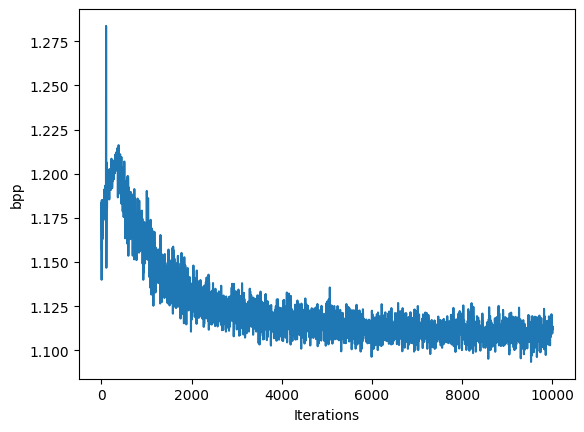

In [20]:
# ADMM
Z_tensor = copy.deepcopy(sr_image_tensor_orig)
T_tensor = torch.zeros_like(sr_image_tensor_orig)

quality_loss_lambda = 1
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = 1e-4, Z_tensor=Z_tensor, T_tensor=T_tensor)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()

In [ ]:
sr_image_tensor_orig = sr_image_tensor_orig.detach()  # Detaches it from any computational graph

In [25]:
import pickle

results = {
    "filename": filename,
    "psnr": psnr_values_,
    "loss_values": loss_values_,
    "bpp_values":bpp_values_,
}

results_file = f"result_2x_{filename}.pkl"
with open(results_file, "wb") as f:
    pickle.dump(results, f)
    
    

In [55]:
# Evaluate performance with the resized image
sr_compression_result_spnet_bitmin = eval_perf_compression(model_compression, Z_tensor, ground_truth_tensor)
sr_compression_result_spnet_bitmin

/tmp/ipykernel_2708812/3460241187.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(33.415466, dtype=float32),
 'Bpp': array(1.1084452, dtype=float32),
 'Bpp(fsize)': 1.020172119140625,
 'SSIM': array(0.03229612, dtype=float32),
 'PSNR_cmpref': array(30.651936, dtype=float32),
 'SSI_cmpref': array(0.0431844, dtype=float32)}

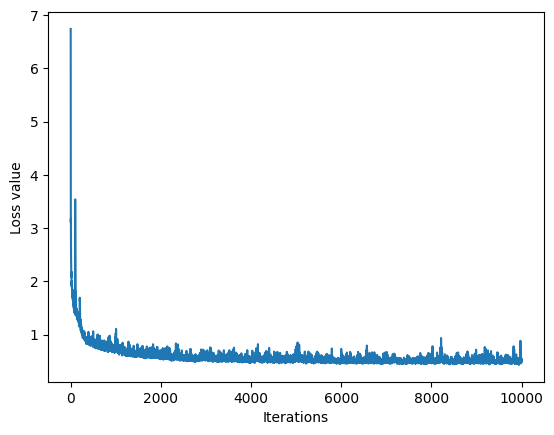

In [22]:
plt.plot(loss_values_)
plt.xlabel("Iterations")
plt.ylabel("Loss value")
plt.show()

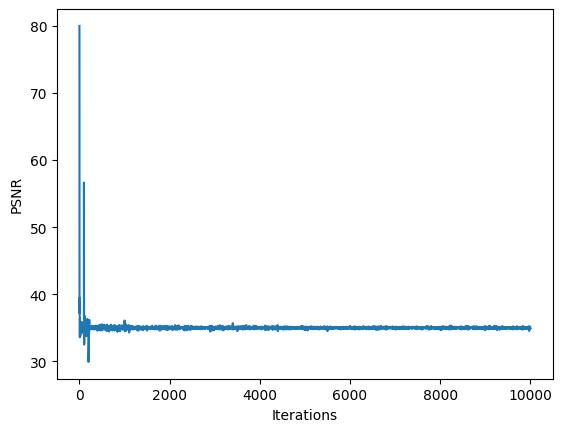

In [23]:
plt.plot(psnr_values_)
plt.xlabel("Iterations")
plt.ylabel("PSNR")
plt.show()

In [51]:
bpp_values_ = np.array(bpp_values_)

np.min(bpp_values_[np.abs(np.array(psnr_values_)-np.float32(target_psnr))<=1e-2])

1.093607783317566

Iteration 0 | PSNR Compressed SR vs Ref: 14.20 | BPP: 0.1415 | Loss: 10.7533
Iteration 30 | PSNR Compressed SR vs Ref: 19.69 | BPP: 0.2828 | Loss: 9.2555
Iteration 60 | PSNR Compressed SR vs Ref: 22.77 | BPP: 0.4150 | Loss: 8.4227
Iteration 90 | PSNR Compressed SR vs Ref: 30.13 | BPP: 0.9205 | Loss: 5.9515
Iteration 0 | PSNR Compressed SR vs Ref: 32.06 | BPP: 1.0376 | Loss: 4.9088
Iteration 30 | PSNR Compressed SR vs Ref: 33.94 | BPP: 1.1382 | Loss: 3.7982
Iteration 60 | PSNR Compressed SR vs Ref: 34.46 | BPP: 1.1584 | Loss: 3.4573
Iteration 90 | PSNR Compressed SR vs Ref: 34.76 | BPP: 1.1695 | Loss: 3.2649
Iteration 0 | PSNR Compressed SR vs Ref: 34.83 | BPP: 1.1762 | Loss: 3.2072
Iteration 30 | PSNR Compressed SR vs Ref: 34.88 | BPP: 1.1752 | Loss: 3.1678
Iteration 60 | PSNR Compressed SR vs Ref: 34.87 | BPP: 1.1819 | Loss: 3.1964
Iteration 90 | PSNR Compressed SR vs Ref: 34.78 | BPP: 1.1403 | Loss: 3.1164
Iteration 0 | PSNR Compressed SR vs Ref: 34.82 | BPP: 1.1506 | Loss: 3.0995
It

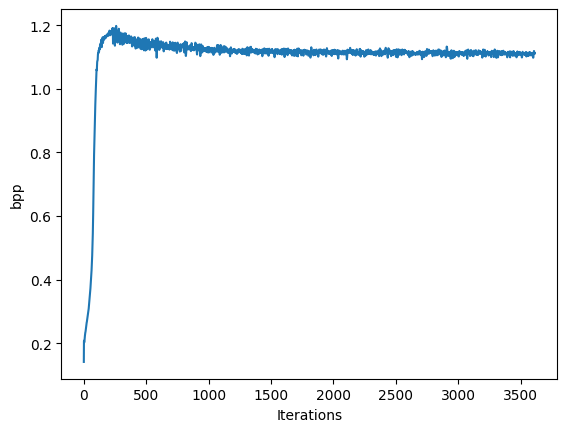

In [57]:
# ADMM
 
quality_loss_lambda = .8
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = 1e-4, Z_tensor=Z_tensor, T_tensor=T_tensor)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()

Iteration 0 | PSNR Compressed SR vs Ref: 35.03 | BPP: 1.1154 | Loss: 2.3319
Iteration 30 | PSNR Compressed SR vs Ref: 34.47 | BPP: 1.0713 | Loss: 2.1792
Iteration 60 | PSNR Compressed SR vs Ref: 34.54 | BPP: 1.0722 | Loss: 2.1595
Iteration 90 | PSNR Compressed SR vs Ref: 34.50 | BPP: 1.0620 | Loss: 2.1221
Iteration 0 | PSNR Compressed SR vs Ref: 34.52 | BPP: 1.0644 | Loss: 2.1227
Iteration 30 | PSNR Compressed SR vs Ref: 34.49 | BPP: 1.0592 | Loss: 2.1064
Iteration 60 | PSNR Compressed SR vs Ref: 34.53 | BPP: 1.0733 | Loss: 2.1577
Iteration 90 | PSNR Compressed SR vs Ref: 34.53 | BPP: 1.0721 | Loss: 2.1531
Iteration 0 | PSNR Compressed SR vs Ref: 34.53 | BPP: 1.0655 | Loss: 2.1214
Iteration 30 | PSNR Compressed SR vs Ref: 34.45 | BPP: 1.0635 | Loss: 2.1549
Iteration 60 | PSNR Compressed SR vs Ref: 34.48 | BPP: 1.0608 | Loss: 2.1145
Iteration 90 | PSNR Compressed SR vs Ref: 34.44 | BPP: 1.0611 | Loss: 2.1505
Iteration 0 | PSNR Compressed SR vs Ref: 34.57 | BPP: 1.0680 | Loss: 2.1239
Ite

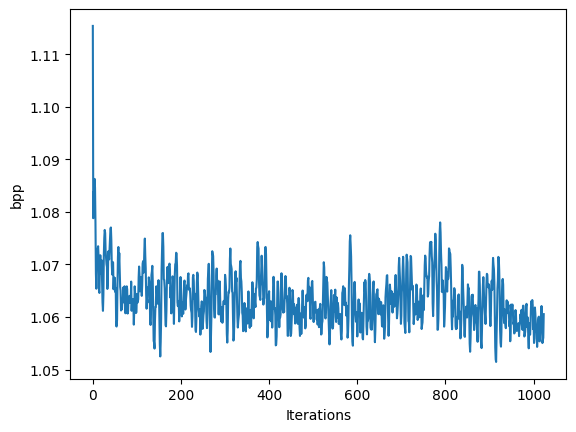

In [60]:
# ADMM
 
quality_loss_lambda = .8
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = 1e-4, Z_tensor=Z_tensor, T_tensor=T_tensor)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()

Iteration 0 | PSNR Compressed SR vs Ref: 34.48 | BPP: 1.1008 | Loss: 2.1806
Iteration 30 | PSNR Compressed SR vs Ref: 34.51 | BPP: 1.0774 | Loss: 2.0753
Iteration 60 | PSNR Compressed SR vs Ref: 34.51 | BPP: 1.0780 | Loss: 2.0780
Interrupted, checkpoint saved.


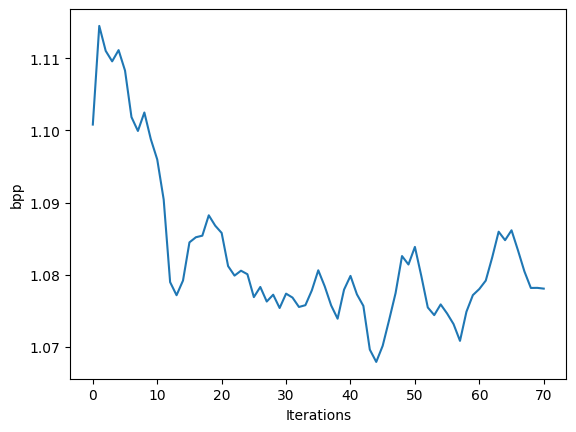

In [62]:
# ADMM
 
quality_loss_lambda = .8
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = 1e-4, Z_tensor=Z_tensor, T_tensor=T_tensor)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()

Iteration 0 | PSNR Compressed SR vs Ref: 34.52 | BPP: 1.0754 | Loss: 1.6294
Iteration 30 | PSNR Compressed SR vs Ref: 34.47 | BPP: 1.0667 | Loss: 1.6102
Iteration 60 | PSNR Compressed SR vs Ref: 34.49 | BPP: 1.0685 | Loss: 1.6061
Iteration 90 | PSNR Compressed SR vs Ref: 34.44 | BPP: 1.0643 | Loss: 1.6217
Iteration 0 | PSNR Compressed SR vs Ref: 34.52 | BPP: 1.0657 | Loss: 1.5833
Iteration 30 | PSNR Compressed SR vs Ref: 34.41 | BPP: 1.0613 | Loss: 1.6174
Iteration 60 | PSNR Compressed SR vs Ref: 34.60 | BPP: 1.0736 | Loss: 1.6152
Iteration 90 | PSNR Compressed SR vs Ref: 34.48 | BPP: 1.0616 | Loss: 1.5814
Iteration 0 | PSNR Compressed SR vs Ref: 34.51 | BPP: 1.0638 | Loss: 1.5689
Iteration 30 | PSNR Compressed SR vs Ref: 34.45 | BPP: 1.0596 | Loss: 1.5794
Iteration 60 | PSNR Compressed SR vs Ref: 34.42 | BPP: 1.0607 | Loss: 1.6060
Iteration 90 | PSNR Compressed SR vs Ref: 34.51 | BPP: 1.0613 | Loss: 1.5585
Iteration 0 | PSNR Compressed SR vs Ref: 34.55 | BPP: 1.0678 | Loss: 1.5789
Ite

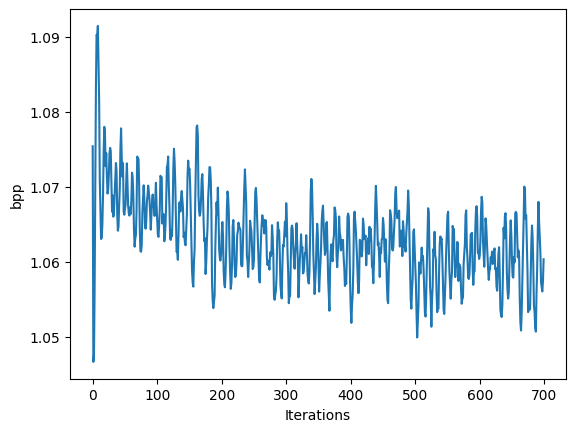

In [63]:
# ADMM
 
quality_loss_lambda = .6
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = 1e-4, Z_tensor=Z_tensor, T_tensor=T_tensor)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()

In [64]:
# Evaluate performance with the resized image
sr_compression_result_spnet_bitmin = eval_perf_compression(model_compression, Z_tensor, ground_truth_tensor)
sr_compression_result_spnet_bitmin

/tmp/ipykernel_2708812/3460241187.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(34.023483, dtype=float32),
 'Bpp': array(1.060328, dtype=float32),
 'Bpp(fsize)': 0.968414306640625,
 'SSIM': array(0.02770799, dtype=float32),
 'PSNR_cmpref': array(30.442322, dtype=float32),
 'SSI_cmpref': array(0.04638366, dtype=float32)}

Iteration 0 | PSNR Compressed SR vs Ref: 34.52 | BPP: 1.0629 | Loss: 12.9728
Iteration 30 | PSNR Compressed SR vs Ref: 34.56 | BPP: 1.0774 | Loss: 12.9152
Iteration 60 | PSNR Compressed SR vs Ref: 34.45 | BPP: 1.0767 | Loss: 12.9037
Iteration 90 | PSNR Compressed SR vs Ref: 34.47 | BPP: 1.0736 | Loss: 12.8532
Iteration 0 | PSNR Compressed SR vs Ref: 34.44 | BPP: 1.0766 | Loss: 12.6520
Iteration 30 | PSNR Compressed SR vs Ref: 34.48 | BPP: 1.0716 | Loss: 12.5932
Iteration 60 | PSNR Compressed SR vs Ref: 34.46 | BPP: 1.0770 | Loss: 12.5979
Iteration 90 | PSNR Compressed SR vs Ref: 34.54 | BPP: 1.0860 | Loss: 12.5901
Iteration 0 | PSNR Compressed SR vs Ref: 34.52 | BPP: 1.0806 | Loss: 12.2924
Iteration 30 | PSNR Compressed SR vs Ref: 34.53 | BPP: 1.0839 | Loss: 12.2895
Iteration 60 | PSNR Compressed SR vs Ref: 34.44 | BPP: 1.0735 | Loss: 12.2625
Iteration 90 | PSNR Compressed SR vs Ref: 34.46 | BPP: 1.0791 | Loss: 12.2560
Iteration 0 | PSNR Compressed SR vs Ref: 34.54 | BPP: 1.0797 | Loss

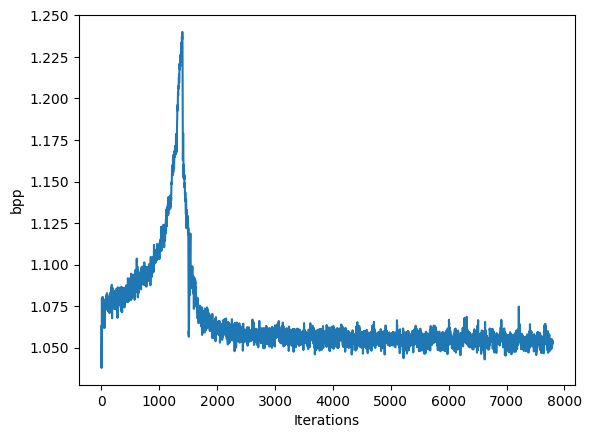

In [66]:
# ADMM
 
quality_loss_lambda = .6
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = 1e-4, Z_tensor=Z_tensor, T_tensor=T_tensor)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()

In [67]:
sr_compression_result_spnet_bitmin = eval_perf_compression(model_compression, Z_tensor, ground_truth_tensor)
sr_compression_result_spnet_bitmin

/tmp/ipykernel_2708812/3460241187.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(33.776814, dtype=float32),
 'Bpp': array(1.0522933, dtype=float32),
 'Bpp(fsize)': 0.960357666015625,
 'SSIM': array(0.03333579, dtype=float32),
 'PSNR_cmpref': array(30.440598, dtype=float32),
 'SSI_cmpref': array(0.04629054, dtype=float32)}

Iteration 0 | PSNR Compressed SR vs Ref: 34.51 | BPP: 1.0526 | Loss: 0.2225
Iteration 30 | PSNR Compressed SR vs Ref: 34.49 | BPP: 1.0525 | Loss: 0.2295
Iteration 60 | PSNR Compressed SR vs Ref: 34.49 | BPP: 1.0557 | Loss: 0.2421
Iteration 90 | PSNR Compressed SR vs Ref: 34.45 | BPP: 1.0519 | Loss: 0.2452
Iteration 0 | PSNR Compressed SR vs Ref: 34.44 | BPP: 1.0511 | Loss: 0.2480
Iteration 30 | PSNR Compressed SR vs Ref: 34.52 | BPP: 1.0513 | Loss: 0.2171
Iteration 60 | PSNR Compressed SR vs Ref: 34.53 | BPP: 1.0576 | Loss: 0.2430
Iteration 90 | PSNR Compressed SR vs Ref: 34.48 | BPP: 1.0596 | Loss: 0.2597
Iteration 0 | PSNR Compressed SR vs Ref: 34.46 | BPP: 1.0505 | Loss: 0.4517
Iteration 30 | PSNR Compressed SR vs Ref: 34.59 | BPP: 1.0577 | Loss: 0.2437
Iteration 60 | PSNR Compressed SR vs Ref: 34.46 | BPP: 1.0519 | Loss: 0.2386
Iteration 90 | PSNR Compressed SR vs Ref: 34.52 | BPP: 1.0527 | Loss: 0.2230
Iteration 0 | PSNR Compressed SR vs Ref: 34.49 | BPP: 1.0506 | Loss: 0.2198
Ite

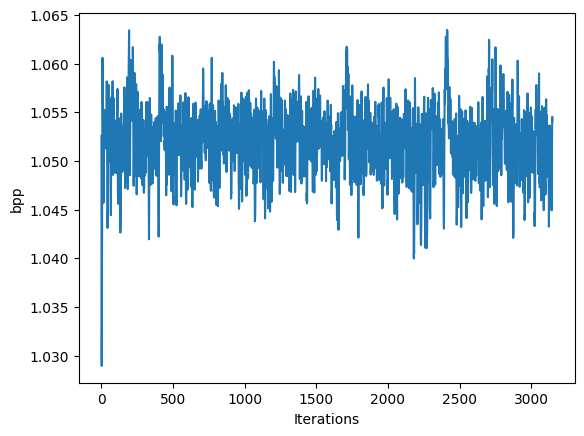

In [68]:
# ADMM
 
quality_loss_lambda = .5
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = 1e-4, Z_tensor=Z_tensor, T_tensor=T_tensor)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()

Iteration 0 | PSNR Compressed SR vs Ref: 34.47 | BPP: 1.0509 | Loss: 0.2221
Iteration 30 | PSNR Compressed SR vs Ref: 32.96 | BPP: 0.9523 | Loss: 0.0955
Iteration 60 | PSNR Compressed SR vs Ref: 32.50 | BPP: 0.9246 | Loss: 0.0596
Iteration 90 | PSNR Compressed SR vs Ref: 32.26 | BPP: 0.9089 | Loss: 0.0331
Iteration 0 | PSNR Compressed SR vs Ref: 32.19 | BPP: 0.9013 | Loss: 0.0108
Iteration 30 | PSNR Compressed SR vs Ref: 31.61 | BPP: 0.8681 | Loss: -0.0372
Iteration 60 | PSNR Compressed SR vs Ref: 31.60 | BPP: 0.8646 | Loss: -0.0513
Iteration 90 | PSNR Compressed SR vs Ref: 31.56 | BPP: 0.8650 | Loss: -0.0420
Iteration 0 | PSNR Compressed SR vs Ref: 31.49 | BPP: 0.8595 | Loss: -0.0556
Iteration 30 | PSNR Compressed SR vs Ref: 31.46 | BPP: 0.8573 | Loss: -0.0606
Iteration 60 | PSNR Compressed SR vs Ref: 31.41 | BPP: 0.8545 | Loss: -0.0650
Interrupted, checkpoint saved.


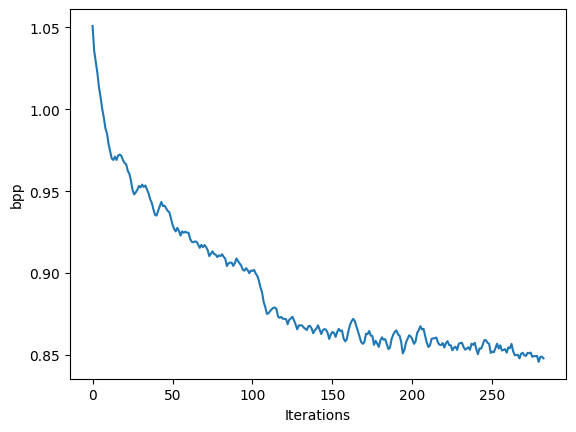

In [69]:
# ADMM
 
quality_loss_lambda = .2
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = 1e-4, Z_tensor=Z_tensor, T_tensor=T_tensor)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()

In [70]:
sr_compression_result_spnet_bitmin = eval_perf_compression(model_compression, Z_tensor, ground_truth_tensor)
sr_compression_result_spnet_bitmin

/tmp/ipykernel_2708812/3460241187.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(34.96033, dtype=float32),
 'Bpp': array(0.91149515, dtype=float32),
 'Bpp(fsize)': 0.811431884765625,
 'SSIM': array(0.02465235, dtype=float32),
 'PSNR_cmpref': array(29.503937, dtype=float32),
 'SSI_cmpref': array(0.05815218, dtype=float32)}

Iteration 0 | PSNR Compressed SR vs Ref: 29.53 | BPP: 0.7406 | Loss: 2.4278
Iteration 30 | PSNR Compressed SR vs Ref: 31.51 | BPP: 0.8736 | Loss: -0.5867
Iteration 60 | PSNR Compressed SR vs Ref: 31.46 | BPP: 0.8563 | Loss: -0.6383
Iteration 90 | PSNR Compressed SR vs Ref: 31.46 | BPP: 0.8567 | Loss: -0.6339
Iteration 0 | PSNR Compressed SR vs Ref: 31.54 | BPP: 0.8596 | Loss: 0.0918
Iteration 30 | PSNR Compressed SR vs Ref: 31.54 | BPP: 0.8659 | Loss: -0.6251
Iteration 60 | PSNR Compressed SR vs Ref: 31.45 | BPP: 0.8560 | Loss: -0.6282
Iteration 90 | PSNR Compressed SR vs Ref: 31.53 | BPP: 0.8568 | Loss: -0.6713
Iteration 0 | PSNR Compressed SR vs Ref: 31.54 | BPP: 0.8578 | Loss: 0.2088
Iteration 30 | PSNR Compressed SR vs Ref: 31.53 | BPP: 0.8579 | Loss: -0.6654
Iteration 60 | PSNR Compressed SR vs Ref: 31.52 | BPP: 0.8547 | Loss: -0.6821
Iteration 90 | PSNR Compressed SR vs Ref: 31.48 | BPP: 0.8522 | Loss: -0.6772
Iteration 0 | PSNR Compressed SR vs Ref: 31.55 | BPP: 0.8545 | Loss: -

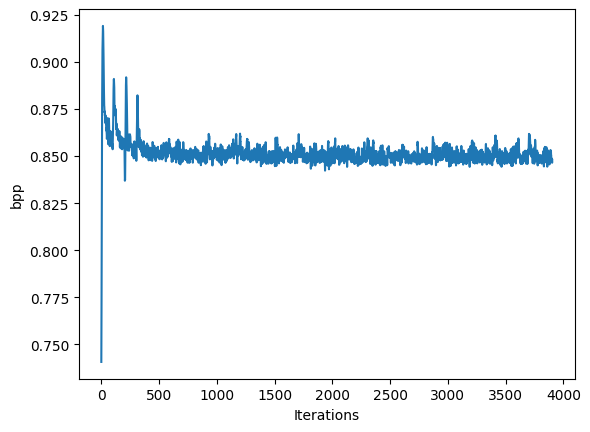

In [75]:
# ADMM
 
quality_loss_lambda = 1
num_iterations = 100
target_psnr = 32

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = 1e-4, Z_tensor=Z_tensor, T_tensor=T_tensor)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()

In [76]:
sr_compression_result_spnet_bitmin = eval_perf_compression(model_compression, Z_tensor, ground_truth_tensor)
sr_compression_result_spnet_bitmin

/tmp/ipykernel_2708812/3460241187.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(33.99604, dtype=float32),
 'Bpp': array(0.8484962, dtype=float32),
 'Bpp(fsize)': 0.746978759765625,
 'SSIM': array(0.03862811, dtype=float32),
 'PSNR_cmpref': array(29.06348, dtype=float32),
 'SSI_cmpref': array(0.06493911, dtype=float32)}